## Treino do Modelo de BCS (Body Condition Score)

Regressão de BCS (escala 3.25–4.25, passos de 0.25) para vacas leiteiras,
a partir de imagens da região da garupa. MobileNetV2 pré-treinado
(ImageNet) + transfer learning em duas fases.

Dataset: ~53.500 imagens, 5.704 vacas, anotação Pascal VOC (XML).


## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:

!pip install -q scikit-learn pandas matplotlib pillow


## 2. Configuração

In [ ]:
import os
import re

DATASET_ROOT = '/content/dataset_BCS_local' 
OUTPUT_DIR = '/content/drive/MyDrive/bcs_training_output'  
os.makedirs(OUTPUT_DIR, exist_ok=True)

MANIFEST_PATH = os.path.join(OUTPUT_DIR, 'manifest.csv')
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, 'best_model.keras')
TFLITE_OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'bcs-model-float32.tflite')
HISTORY_PLOT_PATH = os.path.join(OUTPUT_DIR, 'training_history.png')

BCS_CLASSES = ['3.25', '3.5', '3.75', '4.0', '4.25']
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

FILENAME_PATTERN = re.compile(r'^([A-Za-z]+_\d+)_(\d+)\.(jpg|jpeg|png)$', re.IGNORECASE)
ALT_PATTERN = re.compile(r'^([A-Za-z]+)-i(\d+)\.(jpg|jpeg|png)$', re.IGNORECASE)

## 3. Restaurar o dataset local

In [ ]:
!cp /content/drive/MyDrive/dataset_BCS_local.zip /content/
!cd /content && unzip -q dataset_BCS_local.zip

## 4. Construir o manifest

Varre as 5 pastas de classe, cruza cada imagem com sua anotação XML, e
classifica cada arquivo como tendo agrupamento confiável (ID de vaca
explícito no nome) ou não-confiável (numeração que não separa vacas
de forma segura — ver nota acima).

In [ ]:
import re
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path
from collections import defaultdict

FILENAME_PATTERN = re.compile(r'^([A-Za-z]+_\d+)_(\d+)\.(jpg|jpeg|png)$', re.IGNORECASE)
ALT_PATTERN = re.compile(r'^([A-Za-z]+)-i(\d+)\.(jpg|jpeg|png)$', re.IGNORECASE)


def parse_bcs_from_xml(xml_path):
    try:
        tree = ET.parse(xml_path)
        obj = tree.find('object')
        if obj is None:
            return None
        return obj.find('name').text.strip()
    except Exception:
        return None


def build_manifest(dataset_root, classes):
    rows = []
    mismatches = 0
    standard_pattern_count = 0
    alt_pattern_count = 0

    for bcs_class in classes:
        class_dir = Path(dataset_root) / bcs_class
        if not class_dir.exists():
            print(f'AVISO: pasta não encontrada: {class_dir}')
            continue

        image_files = [
            f for f in class_dir.iterdir()
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')
        ]

        for img_path in image_files:
            xml_path = img_path.with_suffix('.xml')
            if xml_path.exists():
                xml_label = parse_bcs_from_xml(xml_path)
                if xml_label is not None and xml_label != bcs_class:
                    mismatches += 1

            std_match = FILENAME_PATTERN.match(img_path.name)
            if std_match:
                standard_pattern_count += 1
                rows.append({
                    'filepath': str(img_path),
                    'bcs': float(bcs_class),
                    'group': std_match.group(1),
                    'filename': img_path.name,
                    'reliable_group': True,
                })
                continue

            alt_match = ALT_PATTERN.match(img_path.name)
            if alt_match:
                alt_pattern_count += 1
                rows.append({
                    'filepath': str(img_path),
                    'bcs': float(bcs_class),
                    'group': f'{alt_match.group(1).upper()}_{img_path.stem}',
                    'filename': img_path.name,
                    'reliable_group': False,
                })
            else:
                rows.append({
                    'filepath': str(img_path),
                    'bcs': float(bcs_class),
                    'group': f'UNKNOWN_{img_path.stem}',
                    'filename': img_path.name,
                    'reliable_group': False,
                })

    df = pd.DataFrame(rows)
    print(f'Total de imagens encontradas: {len(df)}')
    print(f'Divergências pasta vs. XML: {mismatches}')
    print(f'Padrão principal (GS_id_frame), agrupamento confiável: {standard_pattern_count}')
    print(f'Padrão alternativo (L-i.../R-i...), SEM agrupamento confiável: {alt_pattern_count}')
    print()
    print('Distribuição por classe:')
    print(df['bcs'].value_counts().sort_index())
    print()
    print(f'Imagens confiáveis (vão para o split): {df["reliable_group"].sum()}')
    print(f'Imagens não-confiáveis (vão só para o treino): {(~df["reliable_group"]).sum()}')

    return df


manifest = build_manifest(DATASET_ROOT, BCS_CLASSES)
manifest.to_csv(MANIFEST_PATH, index=False)
manifest.head()

Total de imagens encontradas: 53566
Divergências pasta vs. XML: 0
Padrão principal (GS_id_frame), agrupamento confiável: 44594
Padrão alternativo (L-i.../R-i...), SEM agrupamento confiável: 8972

Distribuição por classe:
bcs
3.25     7536
3.50    13256
3.75    14255
4.00    12556
4.25     5963
Name: count, dtype: int64

Imagens confiáveis (vão para o split): 44594
Imagens não-confiáveis (vão só para o treino): 8972


,filepath,bcs,group,filename,reliable_group
0,/content/dataset_BCS_local/3.25/YM_1727_4.jpg,3.25,YM_1727,YM_1727_4.jpg,True
1,/content/dataset_BCS_local/3.25/GS_1160_2.jpg,3.25,GS_1160,GS_1160_2.jpg,True
2,/content/dataset_BCS_local/3.25/YM_922_4.jpg,3.25,YM_922,YM_922_4.jpg,True
3,/content/dataset_BCS_local/3.25/YM_107_10.jpg,3.25,YM_107,YM_107_10.jpg,True
4,/content/dataset_BCS_local/3.25/GS_1051_1.jpg,3.25,GS_1051,GS_1051_1.jpg,True


## 5. Split treino / validação / teste — por vaca, não por imagem

Usa `GroupShuffleSplit`, garantindo que nenhuma vaca apareça em mais de
um split — com asserts que interrompem a execução se isso acontecer. O
dado sem agrupamento confiável entra inteiro no treino, nunca em
validação/teste.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

def group_split(df, group_col, test_size, seed):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_a, idx_b = next(splitter.split(df, groups=df[group_col]))
    return df.iloc[idx_a].reset_index(drop=True), df.iloc[idx_b].reset_index(drop=True)


reliable_df = manifest[manifest['reliable_group']].reset_index(drop=True)
unreliable_df = manifest[~manifest['reliable_group']].reset_index(drop=True)

print(f"Imagens confiáveis (serão divididas entre treino/val/teste): {len(reliable_df)}")
print(f"Imagens não-confiáveis (vão inteiras para o treino): {len(unreliable_df)}")
print()

# Split (70/15/15) só acontece na parte confiável
train_reliable, temp_df = group_split(reliable_df, 'group', test_size=0.30, seed=SEED)
val_df, test_df = group_split(temp_df, 'group', test_size=0.50, seed=SEED)

# Treino final = parte confiável do treino + TODAS as imagens não-confiáveis
train_df = pd.concat([train_reliable, unreliable_df], ignore_index=True)

# Sanity check crítico: nenhuma vaca confiável pode aparecer em mais de um split
train_groups = set(train_reliable['group'])
val_groups = set(val_df['group'])
test_groups = set(test_df['group'])

assert not (train_groups & val_groups), 'VAZAMENTO: vaca em treino E validação!'
assert not (train_groups & test_groups), 'VAZAMENTO: vaca em treino E teste!'
assert not (val_groups & test_groups), 'VAZAMENTO: vaca em validação E teste!'
print('OK — nenhuma vaca confiável aparece em mais de um split.')
print()

for name, split_df in [('Treino', train_df), ('Validação', val_df), ('Teste', test_df)]:
    n_groups = split_df['group'].nunique()
    print(f'{name}: {len(split_df)} imagens, {n_groups} grupos')
    print(split_df['bcs'].value_counts().sort_index().to_dict())
    print()

Imagens confiáveis (serão divididas entre treino/val/teste): 44594
Imagens não-confiáveis (vão inteiras para o treino): 8972

OK — nenhuma vaca confiável aparece em mais de um split.

Treino: 39957 imagens, 12754 grupos
{3.25: 5586, 3.5: 9972, 3.75: 10548, 4.0: 9335, 4.25: 4516}

Validação: 6854 imagens, 810 grupos
{3.25: 934, 3.5: 1713, 3.75: 1992, 4.0: 1489, 4.25: 726}

Teste: 6755 imagens, 811 grupos
{3.25: 1016, 3.5: 1571, 3.75: 1715, 4.0: 1732, 4.25: 721}



## 6. Pipeline de dados (`tf.data`)

In [ ]:
import tensorflow as tf

def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label


def make_dataset(df, shuffle, batch_size=BATCH_SIZE):
    filepaths = df['filepath'].values
    labels = df['bcs'].values.astype('float32')

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)


## 7. Modelo: MobileNetV2 + cabeça de regressão

Augmentation (flip, brilho, contraste, zoom) embutida no modelo, base
congelada nesta fase, cabeça de regressão nova (saída linear, sem limitar
a faixa de valores).

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
    layers.RandomZoom(0.1),
], name='data_augmentation')


def build_model(img_size, trainable_base=False):
    base_model = keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet',
    )
    base_model.trainable = trainable_base

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = data_augmentation(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=trainable_base)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='linear', name='bcs_output')(x)

    model = keras.Model(inputs, outputs, name='bcs_regressor')
    return model, base_model


model, base_model = build_model(IMG_SIZE, trainable_base=False)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "bcs_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bcs_output (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 2,340,033 (8.93 MB)

Trainable params: 82,049 (320.50 KB)

Non-trainable params: 2,257,984 (8.61 MB)

## 8. Fase 1 — treina só a cabeça (base congelada)

20 épocas, Huber loss, Adam. EarlyStopping e ReduceLROnPlateau como
regularização do processo de treino.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.Huber(),
    metrics=['mae'],
)

callbacks_phase1 = [
    keras.callbacks.EarlyStopping(monitor='val_mae', patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=4, min_lr=1e-6),
]

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_phase1,
)


Epoch 1/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 187s 145ms/step - loss: 0.2121 - mae: 0.5282 - val_loss: 0.0764 - val_mae: 0.3151 - learning_rate: 0.0010
Epoch 2/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 162s 129ms/step - loss: 0.1347 - mae: 0.4171 - val_loss: 0.0659 - val_mae: 0.2956 - learning_rate: 0.0010
Epoch 3/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 186s 117ms/step - loss: 0.1053 - mae: 0.3683 - val_loss: 0.0507 - val_mae: 0.2579 - learning_rate: 0.0010
Epoch 4/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 197s 113ms/step - loss: 0.0822 - mae: 0.3247 - val_loss: 0.0463 - val_mae: 0.2481 - learning_rate: 0.0010
Epoch 5/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 139s 111ms/step - loss: 0.0676 - mae: 0.2951 - val_loss: 0.0418 - val_mae: 0.2355 - learning_rate: 0.0010
Epoch 6/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 141s 113ms/step - loss: 0.0551 - mae: 0.2676 - val_loss: 0.0390 - val_mae: 0.2282 - learning_rate: 0.0010
Epoch 7/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 148s 117ms/step - loss: 0.0475 - mae: 0.2490 - val_loss: 0.0375 - val_

## 9. Fase 2 — fine-tuning (descongela ~30% final da base)

Taxa de aprendizado 100x menor (1e-5) para não destruir os pesos
pré-treinados. ModelCheckpoint salva a melhor versão a cada melhora.

In [ ]:
base_model.trainable = True

# Mantém as camadas mais rasas (features genéricas: bordas, texturas)
# congeladas, e libera só as ~30% finais (features mais específicas).
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.Huber(),
    metrics=['mae'],
)

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(monitor='val_mae', patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=4, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint(CHECKPOINT_PATH, monitor='val_mae', save_best_only=True),
]

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_phase2,
)


Epoch 1/15
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 175s 129ms/step - loss: 0.0366 - mae: 0.2211 - val_loss: 0.0360 - val_mae: 0.2165 - learning_rate: 1.0000e-05
Epoch 2/15
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 161s 129ms/step - loss: 0.0306 - mae: 0.2008 - val_loss: 0.0324 - val_mae: 0.2059 - learning_rate: 1.0000e-05
Epoch 3/15
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 204s 130ms/step - loss: 0.0274 - mae: 0.1881 - val_loss: 0.0310 - val_mae: 0.2014 - learning_rate: 1.0000e-05
Epoch 4/15
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 163s 130ms/step - loss: 0.0253 - mae: 0.1800 - val_loss: 0.0308 - val_mae: 0.2001 - learning_rate: 1.0000e-05
Epoch 5/15
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 201s 130ms/step - loss: 0.0236 - mae: 0.1731 - val_loss: 0.0302 - val_mae: 0.1977 - learning_rate: 1.0000e-05
Epoch 6/15
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 161s 129ms/step - loss: 0.0221 - mae: 0.1667 - val_loss: 0.0304 - val_mae: 0.1981 - learning_rate: 1.0000e-05
Epoch 7/15
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 161s 129ms/step - loss: 0.0210 - mae: 0.1615 -

## 10. Avaliação no conjunto de teste

212/212 ━━━━━━━━━━━━━━━━━━━━ 30s 124ms/step
MAE no teste: 0.207 pontos de BCS
Acerto exato (±0.125): 35.0%
Acerto com tolerância de 1 classe (±0.25): 66.4%


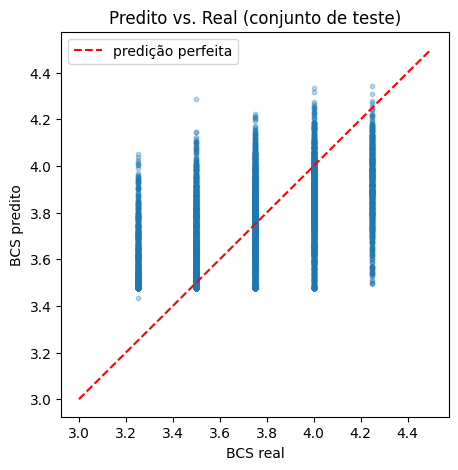

In [ ]:
import numpy as np

y_true = test_df['bcs'].values
y_pred = model.predict(test_ds).flatten()

mae = np.mean(np.abs(y_true - y_pred))
within_exact = np.mean(np.abs(y_true - y_pred) <= 0.125) * 100
within_one_class = np.mean(np.abs(y_true - y_pred) <= 0.25) * 100

print(f'MAE no teste: {mae:.3f} pontos de BCS')
print(f'Acerto exato (±0.125): {within_exact:.1f}%')
print(f'Acerto com tolerância de 1 classe (±0.25): {within_one_class:.1f}%')

plt.figure(figsize=(5, 5))
plt.scatter(y_true, y_pred, alpha=0.3, s=10)
plt.plot([3.0, 4.5], [3.0, 4.5], 'r--', label='predição perfeita')
plt.xlabel('BCS real')
plt.ylabel('BCS predito')
plt.title('Predito vs. Real (conjunto de teste)')
plt.legend()
plt.show()


## 11. Comparação com baseline ingênua

Confirma que o modelo aprende sinal real da imagem, não só "chuta a
média" do dataset.

In [ ]:
import numpy as np

# Baseline: sempre prevê a média do treino, ignorando a imagem
naive_prediction = train_df['bcs'].mean()
naive_mae = np.mean(np.abs(test_df['bcs'].values - naive_prediction))

print(f"MAE do modelo: 0.207")
print(f"MAE da baseline ingênua (sempre prever {naive_prediction:.3f}): {naive_mae:.3f}")

MAE do modelo: 0.207
MAE da baseline ingênua (sempre prever 3.733): 0.255


## 12. Diagnóstico do viés

O erro nas classes extremas (3.25 e 4.25)
é cerca do dobro do erro nas classes centrais, e a predição média por
classe mostra o modelo "comprimindo" as respostas em direção ao centro
da distribuição.

In [ ]:
test_df_eval = test_df.copy()
test_df_eval['pred'] = y_pred  # do bloco de avaliação anterior
test_df_eval['abs_error'] = np.abs(test_df_eval['bcs'] - test_df_eval['pred'])

print(test_df_eval.groupby('bcs')['abs_error'].agg(['mean', 'count']))
print()
print("Predição média por classe real (pra ver se está 'puxando pro centro'):")
print(test_df_eval.groupby('bcs')['pred'].mean())

          mean  count
bcs                  
3.25  0.329718   1016
3.50  0.160655   1571
3.75  0.141017   1715
4.00  0.186790   1732
4.25  0.338205    721

Predição média por classe real (pra ver se está 'puxando pro centro'):
bcs
3.25    3.579718
3.50    3.652127
3.75    3.752572
4.00    3.839959
4.25    3.912363
Name: pred, dtype: float32


## 13. Exportar para TFLite

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(TFLITE_OUTPUT_PATH, 'wb') as f:
    f.write(tflite_model)

print(f'Modelo salvo em: {TFLITE_OUTPUT_PATH}')
print(f'Tamanho: {len(tflite_model) / (1024 * 1024):.1f} MB')


Saved artifact at '/tmp/tmpl0tlu8n4'. The following endpoints are available:

Output Type:
Modelo salvo em: /content/drive/MyDrive/bcs_training_output/bcs-model-float32.tflite
Tamanho: 8.8 MB


## 14. Checagem rápida do `.tflite` exportado

In [ ]:
interpreter = tf.lite.Interpreter(model_path=TFLITE_OUTPUT_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Testa nas primeiras 5 imagens do conjunto de teste
sample = test_df.head(5)
for _, row in sample.iterrows():
    image = tf.io.read_file(row['filepath'])
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.expand_dims(image, 0)

    interpreter.set_tensor(input_details[0]['index'], image)
    interpreter.invoke()
    pred = interpreter.get_tensor(output_details[0]['index'])[0][0]

    print(f"Real: {row['bcs']:.2f}  |  Predito (.tflite): {pred:.3f}  |  Arquivo: {row['filename']}")


Real: 3.25  |  Predito (.tflite): 3.479  |  Arquivo: GS_1160_2.jpg
Real: 3.25  |  Predito (.tflite): 3.483  |  Arquivo: GS_2014_9.jpg
Real: 3.25  |  Predito (.tflite): 3.762  |  Arquivo: GS_3153_3.jpg
Real: 3.25  |  Predito (.tflite): 3.549  |  Arquivo: GS_782_5.jpg
Real: 3.25  |  Predito (.tflite): 3.778  |  Arquivo: YM_1428_1.jpg


    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    for details.
    




- **MAE no teste: 0.207** pontos de BCS
- **Acerto dentro de 0.25: 66.4%**
- Viés nas classes extremas (3.25 e 4.25), motivando a tentativa de
  correção por peso de classe — ver `02_retreino_ponderado.ipynb`
